# RAW/DYR-Based WEC Proxy Simulation

This notebook mirrors the `wec_dynamic_sim.ipynb` workflow but initializes directly from the RAW/DYR pair (`AU14GenModel.RAW`, `AU14GenModel.dyr`).

- Part 1: Load grid + initialize dynamics
- Part 2: Add WEC proxy load (negative load injection)
- Part 3: Read WEC time-series data
- Part 4: Dynamic simulation loop
- Part 5: Verification + quick plots

In [1]:
# Part 1 - Load and initialize the grid from RAW/DYR
import os
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize PSS/E (expects pssepath + psseXX available on host)
import pssepath
pssepath.add_pssepath()
import psse35
import psspy
import dyntools

psse35.set_minor(3)
psspy.psseinit(50)  # PSS/E Xplore is limited to 50 buses

# Resolve file paths - use IEEE 14-bus from cpds_cosim (fits in 50-bus limit)
case_dir = Path.cwd()
if not (case_dir / 'nrel_test').exists():
    case_dir = case_dir  # Already in nrel_test
else:
    case_dir = case_dir / 'nrel_test'

# Use the IEEE 14-bus case which fits within PSS/E Xplore's 50-bus limit
ieee14_dir = (case_dir / '..' / 'cpds_cosim' / 'machine_1' / 'Transmission' / 'ieee_14').resolve()

RAW_FILE = ieee14_dir / 'ieee14.raw'
DYR_FILE = ieee14_dir / 'ieee14.dyr'
OUT_FILE = (case_dir / 'wec_proxy_dynamic.out').resolve()

print(f"RAW: {RAW_FILE}")
print(f"DYR: {DYR_FILE}")
print(f"OUT: {OUT_FILE}")

if not RAW_FILE.exists():
    raise FileNotFoundError(f"RAW file not found: {RAW_FILE}")
if not DYR_FILE.exists():
    raise FileNotFoundError(f"DYR file not found: {DYR_FILE}")

# --- Load case and solve power flow ---
ierr = psspy.read(0, str(RAW_FILE))
print(f"Read RAW: ierr={ierr}")

ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
print(f'Power flow solved: ierr={ierr}')

# Show available buses for reference
ierr, bus_numbers = psspy.abusint(-1, 2, 'NUMBER')
ierr, bus_names = psspy.abuschar(-1, 2, 'NAME')
print(f"\nSystem has {len(bus_numbers[0])} buses")
print("All buses:", list(zip(bus_numbers[0], [n.strip() for n in bus_names[0]])))

    Sets PSSE environment to latest minor version among installed versions of PSSE 35.
    Use psse35.set_minor(n) to set PSSE35 minor version (n) to use.
        Example, for PSSE 35.0.x, use this as: psse35.set_minor(0)

 PSS(R)E Xplore Version 35
 Copyright (c) 1976-2025
 Siemens Industry, Inc.,
 Power Technologies International                            (PTI)
 This program is a confidential  unpublished  work  created  and  first
 licensed in 1976.  It is a trade secret which is the property of  PTI.
 All use,  disclosure,  and/or reproduction not specifically authorized
 by  PTI  is prohibited.   This  program is protected  under  copyright
 laws  of  non-U.S.  countries  and  by  application  of  international
 treaties.  All  Rights  Reserved  Under  The  Copyright  Laws.

 Could not find entry point runpy_add_to_sys_path

           SIEMENS POWER TECHNOLOGIES INTERNATIONAL

    50 BUS POWER SYSTEM SIMULATOR--PSS(R)E Xplore-35.5.2

             INITIATED ON FRI, NOV 28 2025  16

In [2]:
# Part 2 - Add the WEC proxy load (negative load = generation)
# For IEEE 14-bus: Use bus 11 (load bus at network edge, good for offshore WEC)
# Bus 11 already has a load (3.5 MW) - we'll add a new load ID for WEC proxy

wec_bus = 11
wec_load_id = 'W1'  # Different from existing '1 ' load

def add_wec_proxy_load(bus_number, load_id):
    """
    Add a new load entry to serve as WEC proxy.
    Uses load_data_6 which is the PSS/E 35 API for adding loads.
    
    INTGAR array for load_data_6:
      [STATUS, AREA, ZONE, OWNER, SCALE, INTRPT, DESSION]
    
    REALAR array:
      [PL, QL, IP, IQ, YP, YQ] - all in MW/Mvar
    """
    intgar = [1, 0, 0, 1, 1, 0, 0]  # In-service, inherit area/zone
    realar = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  # Zero initial power
    
    ierr = psspy.load_data_6(bus_number, load_id, intgar, realar)
    
    if ierr == 0:
        print(f"✓ Added WEC proxy load '{load_id}' at bus {bus_number}")
    elif ierr == 1:
        print(f"  Load '{load_id}' exists, resetting to zero...")
        ierr = psspy.load_chng_5(bus_number, load_id, [1], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    else:
        print(f"✗ Error adding load: ierr={ierr}")
    return ierr

# Verify bus exists
ierr, base_kv = psspy.busdat(wec_bus, 'BASE')
if ierr == 0:
    print(f"Bus {wec_bus} exists (Base kV: {base_kv:.1f})")
    add_wec_proxy_load(wec_bus, wec_load_id)
else:
    raise RuntimeError(f"Bus {wec_bus} not found!")

# Re-solve power flow after adding load
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
print(f"Power flow re-solved: ierr={ierr}")

# Load dynamics and initialize
psspy.dyre_new([1, 1, 1, 1], str(DYR_FILE), '', '', '')
psspy.cong(0)   # Convert generators
psspy.ordr(0)   # Order network  
psspy.fact()    # Factorize admittance matrix
psspy.tysl(0)   # Initialize time-step simulation
print('✓ Dynamic models loaded and initialized')

Bus 11 exists (Base kV: 138.0)

 Messages for api LOAD_DATA_6
 Messages for load "W1" at bus 11 [BUS11       138.00]:   (002369)
 Error: Invalid area number: 0; set to 2   (002371)
 Error: Invalid zone number: 0; set to 2   (002371)

 Load "W1" at bus 11 [BUS11       138.00] added. Power flow data items with non-default values:
 X--DEFAULT---X  X---ACTUAL---X  DATA ITEM
          2               1      OWNER
✗ Error adding load: ierr=-1

  ITER       DELTAP      BUS         DELTAQ      BUS        DELTA/V/      BUS       DELTAANG      BUS
   0         0.0001(      8     )    0.0000(      9     )
                                                             0.03136(     12     )   0.00278(      2     )
   1         0.0008(      6     )    0.1542(      2     )
                                                             0.02359(      6     )   0.00239(      6     )
   2         0.0006(      6     )    0.0514(      3     )
                                                             0.01062

In [3]:
# Part 3 - Read WEC time-series data from database

database_path = (case_dir / '..' / 'examples' / 'WECGrid.db').resolve()
print(f"Database: {database_path}")

if not database_path.exists():
    raise FileNotFoundError(f"Database not found: {database_path}")

wec_sim_id = 1  # RM3 device simulation
NUM_WEC_DEVICES = 50  # Scale to a 50-device farm

conn = sqlite3.connect(database_path)

# Query WEC power results
query = '''
    SELECT time_sec, device_index, p_w, q_var, wave_elevation_m
    FROM wec_power_results
    WHERE wec_sim_id = ?
    ORDER BY time_sec, device_index
'''
wec_power_df = pd.read_sql_query(query, conn, params=(wec_sim_id,))
conn.close()

if wec_power_df.empty:
    raise RuntimeError(f'No WEC data for wec_sim_id={wec_sim_id}')

print(f"Loaded {len(wec_power_df)} rows of WEC data")
print(f"Time range: {wec_power_df['time_sec'].min():.1f} to {wec_power_df['time_sec'].max():.1f} s")

# Aggregate across devices and scale to farm
farm_power = (
    wec_power_df.groupby('time_sec')
    .agg({'p_w': 'sum', 'q_var': 'sum'})
    .reset_index()
)
farm_power['p_mw'] = farm_power['p_w'] / 1e6
farm_power['q_mvar'] = farm_power['q_var'] / 1e6
farm_power['p_mw_scaled'] = farm_power['p_mw'] * NUM_WEC_DEVICES
farm_power['q_mvar_scaled'] = farm_power['q_mvar'] * NUM_WEC_DEVICES

# Select oscillatory window (after WEC ramp-up)
sim_step = 0.1  # seconds
wec_time_start = 100.0
wec_time_end = 150.0

profile = farm_power.query('time_sec >= @wec_time_start and time_sec <= @wec_time_end').copy()
profile = profile.reset_index(drop=True)
profile['sim_time'] = np.arange(len(profile)) * sim_step

print(f"\nWEC Farm ({NUM_WEC_DEVICES} devices):")
print(f"  Using window: {wec_time_start}s to {wec_time_end}s")
print(f"  Power range: {profile['p_mw_scaled'].min():.3f} to {profile['p_mw_scaled'].max():.3f} MW")
print(f"  Mean power: {profile['p_mw_scaled'].mean():.3f} MW")
print(f"  Time steps: {len(profile)}")

Database: C:\Users\alexb\research\WEC-GRID\examples\WECGrid.db


Loaded 864001 rows of WEC data
Time range: 0.0 to 86400.0 s

WEC Farm (50 devices):
  Using window: 100.0s to 150.0s
  Power range: 0.655 to 0.710 MW
  Mean power: 0.686 MW
  Time steps: 501

WEC Farm (50 devices):
  Using window: 100.0s to 150.0s
  Power range: 0.655 to 0.710 MW
  Mean power: 0.686 MW
  Time steps: 501


In [4]:
# Part 4 - Dynamic simulation loop using the proxy load
# Configure output channels
psspy.progress_output(6, '', [0, 0])  # silence setup chatter
psspy.chsb(0, 1, [-1, -1, -1, 1, 13, 0])  # voltages for all buses
psspy.chsb(0, 1, [-1, -1, -1, 1, 12, 0])  # frequencies for all buses

# Start simulation and flat run (force legacy .out format with intgar=[0,0])
ierr = psspy.strt_2([0, 0], str(OUT_FILE))
if ierr != 0:
    raise RuntimeError(f"strt_2 failed (ierr={ierr}) for OUT_FILE={OUT_FILE}")
psspy.run(0, 0.0, 1, 1, 0)

results = []
current_time = 0.0

for _, row in profile.iterrows():
    target_time = current_time + sim_step
    p_mw = float(row['p_mw_scaled'])
    q_mvar = float(row['q_mvar_scaled'])

    # Negative load injects power (IBR proxy)
    psspy.load_chng_5(wec_bus, wec_load_id, [], [-p_mw, -q_mvar, 0.0, 0.0, 0.0, 0.0])
    psspy.run(0, target_time, 1, 1, 0)

    # Capture voltage directly from PSS/E (more reliable than output file)
    ierr, voltage_pu = psspy.busdat(wec_bus, 'PU')
    
    results.append({
        'sim_time': target_time,
        'wec_p_mw': p_mw,
        'wec_q_mvar': q_mvar,
        'bus_voltage_pu': voltage_pu if ierr == 0 else 1.0
    })
    current_time = target_time

psspy.progress_output(1, '', [0, 0])  # Re-enable output

print(f"✓ Completed dynamic run to t={current_time:.2f} s with {len(results)} steps")
results_df = pd.DataFrame(results)
print(f"  Voltage range: {results_df['bus_voltage_pu'].min():.4f} to {results_df['bus_voltage_pu'].max():.4f} pu")

✓ Completed dynamic run to t=50.10 s with 501 steps
  Voltage range: 0.9928 to 0.9938 pu


Attempting to read output file: C:\Users\alexb\research\WEC-GRID\nrel_test\wec_proxy_dynamic.out

 Extended dynamics channel output file format (.outx) can not be processed from dyntools
     in PSSE version 33. Instead use dynamics channel output file format (.out).
     The dyntools module from PSSE version 34 or later can be used to process .outx files.


 Error reading file, ignored:
     c:\users\alexb\research\wec-grid\nrel_test\wec_proxy_dynamic.out

⚠ Could not read frequency from output file: 'c:\\users\\alexb\\research\\wec-grid\\nrel_test\\wec_proxy_dynamic.out'
  Using nominal 60 Hz for frequency (voltage still captured)


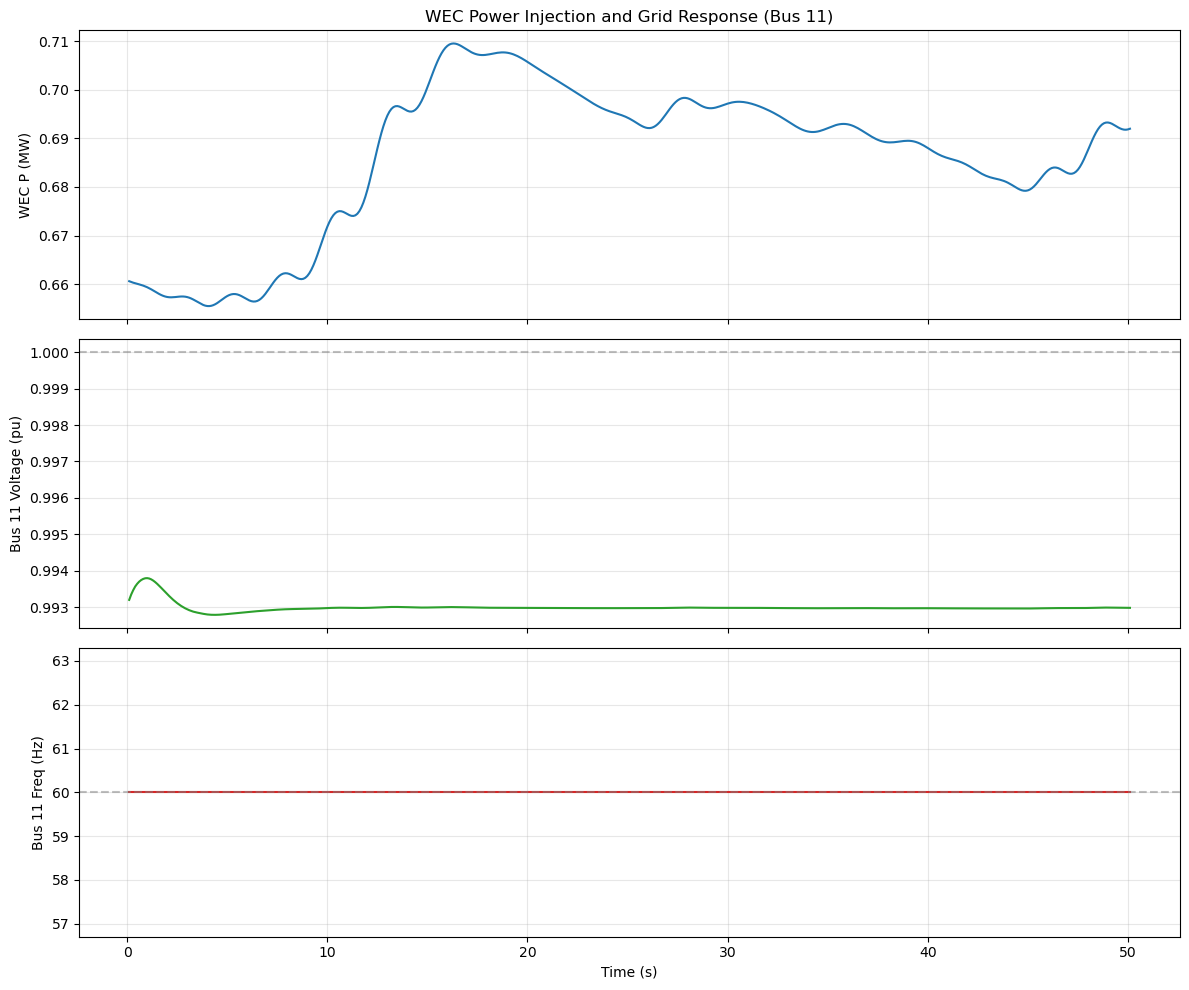


--- Simulation Summary ---
Duration: 50.1 s (501 steps)
WEC Power: 0.655 to 0.710 MW
Voltage:   0.9928 to 0.9938 pu
Frequency: 60.0000 to 60.0000 Hz

Correlation (WEC Power vs Voltage): -0.1649


In [5]:
# Part 5 - Verification and quick analysis
# Voltage was captured in Part 4; now try to extract frequency from .out file

out_path = Path(OUT_FILE)

# Attempt to read frequency from output file (graceful fallback if fails)
freq_data = None
try:
    if out_path.exists():
        print(f"Attempting to read output file: {out_path}")
        chnfobj = dyntools.CHNF(str(out_path))
        short_title, chanid, chandata = chnfobj.get_data()
        
        print(f"  Loaded {len(chanid)} channels")
        out_time = np.array(chandata['time'])
        
        # Find frequency channel for our bus
        bus_tag = f"BUS {wec_bus}".upper()
        freq_key = None
        for k, v in chanid.items():
            if k == 'time':
                continue
            name = str(v).upper()
            if 'FREQ' in name and bus_tag in name:
                freq_key = k
                break
        
        if freq_key is None:
            # Try any frequency channel
            for k, v in chanid.items():
                if k == 'time':
                    continue
                if 'FREQ' in str(v).upper():
                    freq_key = k
                    break
        
        if freq_key:
            freq_pu = np.array(chandata[freq_key])
            freq_hz = (1.0 + freq_pu) * 60.0
            # Interpolate to match our time points
            results_df['bus_freq_hz'] = np.interp(
                results_df['sim_time'], out_time, freq_hz
            )
            print(f"  ✓ Frequency extracted from channel {freq_key}")
        else:
            raise KeyError("No FREQ channel found")
            
except Exception as e:
    print(f"⚠ Could not read frequency from output file: {e}")
    print("  Using nominal 60 Hz for frequency (voltage still captured)")
    results_df['bus_freq_hz'] = 60.0

# Create visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(results_df['sim_time'], results_df['wec_p_mw'], color='tab:blue')
axes[0].set_ylabel('WEC P (MW)')
axes[0].set_title(f'WEC Power Injection and Grid Response (Bus {wec_bus})')
axes[0].grid(alpha=0.3)

axes[1].plot(results_df['sim_time'], results_df['bus_voltage_pu'], color='tab:green')
axes[1].set_ylabel(f'Bus {wec_bus} Voltage (pu)')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3)

axes[2].plot(results_df['sim_time'], results_df['bus_freq_hz'], color='tab:red')
axes[2].set_ylabel(f'Bus {wec_bus} Freq (Hz)')
axes[2].axhline(60.0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Time (s)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n--- Simulation Summary ---")
print(f"Duration: {results_df['sim_time'].iloc[-1]:.1f} s ({len(results_df)} steps)")
print(f"WEC Power: {results_df['wec_p_mw'].min():.3f} to {results_df['wec_p_mw'].max():.3f} MW")
print(f"Voltage:   {results_df['bus_voltage_pu'].min():.4f} to {results_df['bus_voltage_pu'].max():.4f} pu")
print(f"Frequency: {results_df['bus_freq_hz'].min():.4f} to {results_df['bus_freq_hz'].max():.4f} Hz")

# Show correlation between WEC power and voltage
corr = results_df['wec_p_mw'].corr(results_df['bus_voltage_pu'])
print(f"\nCorrelation (WEC Power vs Voltage): {corr:.4f}")

---

## Part 6: IBR Proxy Model (FMU Stand-in)

This section implements a basic **Inverter-Based Resource (IBR) proxy** that mimics an FMU interface.

### IBR Control Modes

The proxy supports grid-following behavior with:
- **Voltage droop**: Adjusts reactive power Q based on voltage deviation
- **Frequency droop**: Adjusts active power P based on frequency deviation
- **Power setpoint**: Base power from WEC database (time-series)

### Interface Design

```
┌─────────────────────────────────────────────┐
│              IBR Proxy Model                │
│  (Stand-in for FMU co-simulation)           │
├─────────────────────────────────────────────┤
│  INPUTS:                                    │
│    • voltage_pu  (from PSS/E busdat)        │
│    • freq_hz     (from PSS/E or nominal)    │
│    • time_sec    (simulation time)          │
│                                             │
│  OUTPUTS:                                   │
│    • P_mw        (active power injection)   │
│    • Q_mvar      (reactive power injection) │
│                                             │
│  PARAMETERS:                                │
│    • p_setpoint  (from WEC database)        │
│    • v_droop     (Q response to ΔV)         │
│    • f_droop     (P response to Δf)         │
└─────────────────────────────────────────────┘
```

In [6]:
# Part 6 - IBR Proxy Class (FMU Stand-in)

class IBRProxy:
    """
    Basic Inverter-Based Resource (IBR) proxy model.
    
    This class serves as a stand-in for an FMU-based IBR model.
    It takes grid conditions (V, f) and outputs P, Q based on:
      - A power setpoint from WEC time-series data
      - Voltage droop control for reactive power
      - Frequency droop control for active power
    
    Future: Replace this with actual FMU calls via PyFMI.
    """
    
    def __init__(self, 
                 power_profile: pd.DataFrame,
                 p_column: str = 'p_mw_scaled',
                 q_column: str = 'q_mvar_scaled',
                 time_column: str = 'sim_time',
                 v_nominal: float = 1.0,
                 f_nominal: float = 60.0,
                 v_droop: float = 0.05,      # 5% droop: ΔQ/ΔV ratio
                 f_droop: float = 0.04,      # 4% droop: ΔP/Δf ratio
                 q_max: float = 10.0,        # Max reactive power (Mvar)
                 p_rated: float = 10.0):     # Rated active power (MW)
        """
        Initialize IBR proxy with power profile and control parameters.
        
        Args:
            power_profile: DataFrame with time-series P/Q setpoints
            p_column: Column name for active power (MW)
            q_column: Column name for reactive power (Mvar)
            time_column: Column name for time (s)
            v_nominal: Nominal voltage (pu)
            f_nominal: Nominal frequency (Hz)
            v_droop: Voltage droop coefficient (ΔQ per pu ΔV)
            f_droop: Frequency droop coefficient (ΔP per Hz Δf)
            q_max: Maximum reactive power capability (Mvar)
            p_rated: Rated power for droop calculation (MW)
        """
        self.profile = power_profile.copy()
        self.p_col = p_column
        self.q_col = q_column
        self.t_col = time_column
        
        self.v_nom = v_nominal
        self.f_nom = f_nominal
        self.v_droop = v_droop
        self.f_droop = f_droop
        self.q_max = q_max
        self.p_rated = p_rated
        
        # Pre-compute interpolation arrays for efficiency
        self._t_array = self.profile[time_column].values
        self._p_array = self.profile[p_column].values
        self._q_array = self.profile[q_column].values if q_column in self.profile.columns else np.zeros_like(self._p_array)
        
        # State tracking
        self.call_count = 0
        self.last_inputs = {}
        self.last_outputs = {}
    
    def get_setpoint(self, time_sec: float) -> tuple:
        """Get base P/Q setpoint from WEC profile at given time."""
        p_set = float(np.interp(time_sec, self._t_array, self._p_array))
        q_set = float(np.interp(time_sec, self._t_array, self._q_array))
        return p_set, q_set
    
    def compute_output(self, 
                       voltage_pu: float, 
                       freq_hz: float, 
                       time_sec: float) -> dict:
        """
        Compute IBR output based on grid conditions.
        
        This is the main interface - analogous to FMU doStep().
        
        Args:
            voltage_pu: Bus voltage magnitude (per-unit)
            freq_hz: Bus frequency (Hz)
            time_sec: Current simulation time (s)
            
        Returns:
            dict with 'P_mw', 'Q_mvar', and diagnostic info
        """
        self.call_count += 1
        
        # Get base setpoint from WEC profile
        p_setpoint, q_setpoint = self.get_setpoint(time_sec)
        
        # Voltage droop: Adjust Q to support voltage
        # Under-voltage (V < 1.0): Inject Q (capacitive)
        # Over-voltage (V > 1.0): Absorb Q (inductive)
        delta_v = self.v_nom - voltage_pu
        q_droop = (delta_v / self.v_droop) * self.q_max  # Mvar adjustment
        
        # Frequency droop: Adjust P for frequency support
        # Under-frequency (f < 60): Increase P
        # Over-frequency (f > 60): Decrease P
        delta_f = self.f_nom - freq_hz
        p_droop = (delta_f / self.f_droop) * self.p_rated  # MW adjustment
        
        # Combine setpoint + droop response
        p_output = p_setpoint + p_droop
        q_output = q_setpoint + q_droop
        
        # Apply limits
        q_output = np.clip(q_output, -self.q_max, self.q_max)
        p_output = max(0, p_output)  # WEC can't absorb power
        
        # Store for diagnostics
        self.last_inputs = {
            'time_sec': time_sec,
            'voltage_pu': voltage_pu,
            'freq_hz': freq_hz
        }
        self.last_outputs = {
            'P_mw': p_output,
            'Q_mvar': q_output,
            'P_setpoint': p_setpoint,
            'Q_setpoint': q_setpoint,
            'P_droop': p_droop,
            'Q_droop': q_droop,
            'delta_v': delta_v,
            'delta_f': delta_f
        }
        
        return {
            'P_mw': p_output,
            'Q_mvar': q_output,
            'P_setpoint': p_setpoint,
            'P_droop': p_droop,
            'Q_droop': q_droop
        }
    
    def __repr__(self):
        return (f"IBRProxy(v_droop={self.v_droop}, f_droop={self.f_droop}, "
                f"p_rated={self.p_rated} MW, q_max={self.q_max} Mvar)")


# Instantiate IBR proxy with our WEC profile
ibr = IBRProxy(
    power_profile=profile,
    p_column='p_mw_scaled',
    q_column='q_mvar_scaled',
    time_column='sim_time',
    p_rated=profile['p_mw_scaled'].max(),  # Use peak WEC power
    q_max=profile['p_mw_scaled'].max() * 0.5,  # 50% reactive capability
    v_droop=0.05,  # 5% voltage droop
    f_droop=0.04   # 4% frequency droop (typical for IBR)
)

print(f"Created: {ibr}")
print(f"Power profile: {len(profile)} time steps")
print(f"P range: {profile['p_mw_scaled'].min():.3f} to {profile['p_mw_scaled'].max():.3f} MW")

# Test the IBR at nominal conditions
test_out = ibr.compute_output(voltage_pu=1.0, freq_hz=60.0, time_sec=5.0)
print(f"\nTest at nominal (V=1.0, f=60Hz, t=5s):")
print(f"  P = {test_out['P_mw']:.3f} MW (setpoint: {test_out['P_setpoint']:.3f}, droop: {test_out['P_droop']:.3f})")
print(f"  Q = {test_out['Q_mvar']:.3f} Mvar")

# Test with voltage deviation
test_out = ibr.compute_output(voltage_pu=0.95, freq_hz=60.0, time_sec=5.0)
print(f"\nTest with low voltage (V=0.95, f=60Hz):")
print(f"  P = {test_out['P_mw']:.3f} MW")
print(f"  Q = {test_out['Q_mvar']:.3f} Mvar (Q droop: {test_out['Q_droop']:.3f})")

# Test with frequency deviation  
test_out = ibr.compute_output(voltage_pu=1.0, freq_hz=59.9, time_sec=5.0)
print(f"\nTest with low frequency (V=1.0, f=59.9Hz):")
print(f"  P = {test_out['P_mw']:.3f} MW (P droop: {test_out['P_droop']:.3f})")
print(f"  Q = {test_out['Q_mvar']:.3f} Mvar")

Created: IBRProxy(v_droop=0.05, f_droop=0.04, p_rated=0.7095293019110782 MW, q_max=0.3547646509555391 Mvar)
Power profile: 501 time steps
P range: 0.655 to 0.710 MW

Test at nominal (V=1.0, f=60Hz, t=5s):
  P = 0.658 MW (setpoint: 0.658, droop: 0.000)
  Q = 0.000 Mvar

Test with low voltage (V=0.95, f=60Hz):
  P = 0.658 MW
  Q = 0.355 Mvar (Q droop: 0.355)

Test with low frequency (V=1.0, f=59.9Hz):
  P = 2.432 MW (P droop: 1.774)
  Q = 0.000 Mvar


### Part 6b: Run Simulation with IBR Proxy

Now we re-run the dynamic simulation but use the IBR proxy class to compute P/Q outputs.
This demonstrates the FMU-style interface where:
1. PSS/E provides grid state (V, f)
2. IBR proxy computes response (P, Q)
3. PSS/E receives updated injection

In [7]:
# Part 6b - Re-run simulation using IBR proxy
# Need to reinitialize PSS/E case for clean run

# Reload case
psspy.case(str(RAW_FILE))
psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])

# Re-add the WEC proxy load
psspy.load_data_6(wec_bus, wec_load_id, [1, 0, 0, 1, 1, 0, 0], [0.0]*6)
psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])

# Load dynamics
psspy.dyre_new([1, 1, 1, 1], str(DYR_FILE), '', '', '')
psspy.cong(0)
psspy.ordr(0)
psspy.fact()
psspy.tysl(0)

# Configure output
OUT_FILE_IBR = case_dir / 'wec_ibr_proxy.out'
psspy.progress_output(6, '', [0, 0])
psspy.chsb(0, 1, [-1, -1, -1, 1, 13, 0])  # voltages
psspy.chsb(0, 1, [-1, -1, -1, 1, 12, 0])  # frequencies

# Start simulation
ierr = psspy.strt_2([0, 0], str(OUT_FILE_IBR))
psspy.run(0, 0.0, 1, 1, 0)

# Create fresh IBR proxy instance
ibr = IBRProxy(
    power_profile=profile,
    p_column='p_mw_scaled',
    q_column='q_mvar_scaled', 
    time_column='sim_time',
    p_rated=profile['p_mw_scaled'].max(),
    q_max=profile['p_mw_scaled'].max() * 0.5,
    v_droop=0.05,
    f_droop=0.04
)

# Run simulation loop with IBR proxy
ibr_results = []
current_time = 0.0

print("Running IBR-proxy co-simulation loop...")
for i, (_, row) in enumerate(profile.iterrows()):
    target_time = current_time + sim_step
    
    # Step 1: Get grid state from PSS/E
    ierr, voltage_pu = psspy.busdat(wec_bus, 'PU')
    freq_hz = 60.0  # Use nominal for now (dyntools issue)
    
    # Step 2: Call IBR proxy (this is where FMU would be called)
    ibr_output = ibr.compute_output(
        voltage_pu=voltage_pu,
        freq_hz=freq_hz,
        time_sec=target_time
    )
    
    # Step 3: Apply IBR output to PSS/E load
    # Negative load = generation (power injection)
    psspy.load_chng_5(
        wec_bus, wec_load_id, [],
        [-ibr_output['P_mw'], -ibr_output['Q_mvar'], 0.0, 0.0, 0.0, 0.0]
    )
    
    # Step 4: Advance PSS/E simulation
    psspy.run(0, target_time, 1, 1, 0)
    
    # Record results
    ibr_results.append({
        'sim_time': target_time,
        'voltage_pu': voltage_pu,
        'freq_hz': freq_hz,
        'P_setpoint': ibr_output['P_setpoint'],
        'P_output': ibr_output['P_mw'],
        'P_droop': ibr_output['P_droop'],
        'Q_output': ibr_output['Q_mvar'],
        'Q_droop': ibr_output['Q_droop']
    })
    
    current_time = target_time

psspy.progress_output(1, '', [0, 0])

ibr_results_df = pd.DataFrame(ibr_results)
print(f"✓ IBR co-simulation complete: {len(ibr_results_df)} steps")
print(f"  IBR calls: {ibr.call_count}")
print(f"  P range: {ibr_results_df['P_output'].min():.3f} to {ibr_results_df['P_output'].max():.3f} MW")
print(f"  Q range: {ibr_results_df['Q_output'].min():.3f} to {ibr_results_df['Q_output'].max():.3f} Mvar")

 Not open for physical access. C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.raw (RWFIL/CASE34)

 Messages for api FNSL
 Generators are "converted"   (001813)

 Messages for api LOAD_DATA_6
 Messages for load "W1" at bus 11 [BUS11       138.00]:   (002369)
 Error: Invalid area number: 0; set to 2   (002371)
 Error: Invalid zone number: 0; set to 2   (002371)

 Power flow data changed for load "W1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.691983         0.00000      PL

 Messages for api FNSL
 Generators are "converted"   (001813)

 Input error detected at !
   Line  'Toggle'  Line_1  1.0
   !

 RECORD IGNORED:
   Line  'Toggle'  Line_1  1.0 /

 Input error detected at !
   Line  'Toggle'  Line_1  1.1
   !

 RECORD IGNORED:
   Line  'Toggle'  Line_1  1.1 /
 Out of file data--switch to terminal input mode

 Generator models use:
  CONS         1-     70
  STATES       1-     30

 Stabilizer models use:
  CONS     

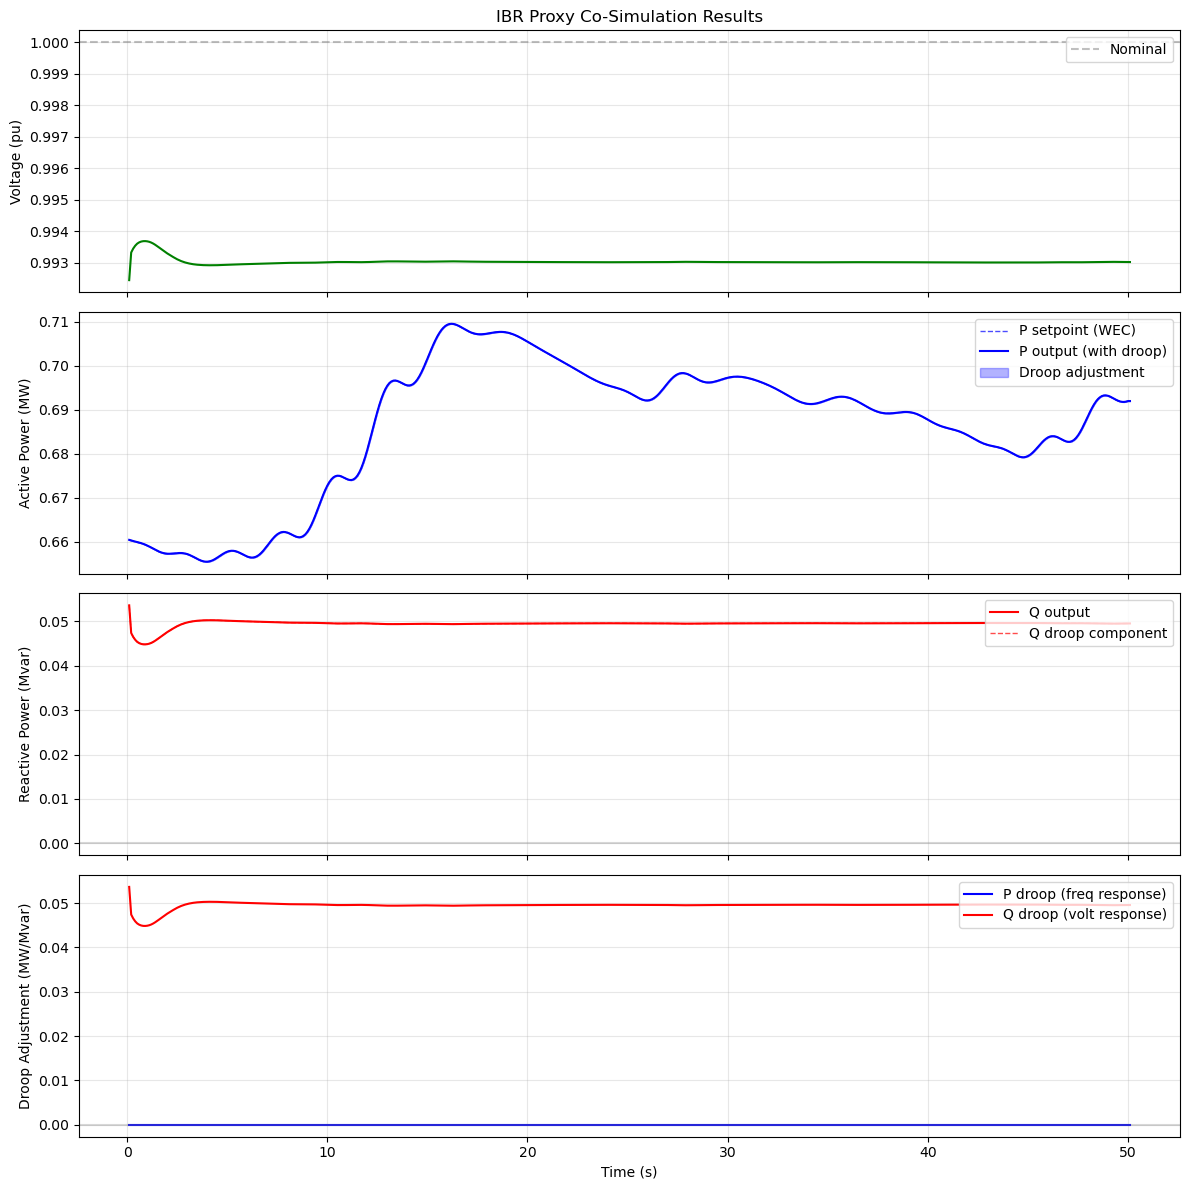


--- IBR Proxy Summary ---
Simulation: 50.1 s, 501 steps

Voltage:
  Range: 0.9924 to 0.9937 pu
  Mean deviation from 1.0: 0.00697 pu

Active Power:
  Setpoint range: 0.655 to 0.710 MW
  Output range:   0.655 to 0.710 MW
  Max P droop:    0.000 MW

Reactive Power:
  Q output range: 0.045 to 0.054 Mvar
  Max Q droop:    0.054 Mvar


In [8]:
# Part 6c - Visualize IBR proxy behavior

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Plot 1: Voltage at IBR bus
ax1 = axes[0]
ax1.plot(ibr_results_df['sim_time'], ibr_results_df['voltage_pu'], 'g-', lw=1.5)
ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Nominal')
ax1.set_ylabel('Voltage (pu)')
ax1.set_title('IBR Proxy Co-Simulation Results')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# Plot 2: Active Power (setpoint vs output)
ax2 = axes[1]
ax2.plot(ibr_results_df['sim_time'], ibr_results_df['P_setpoint'], 'b--', 
         lw=1, alpha=0.7, label='P setpoint (WEC)')
ax2.plot(ibr_results_df['sim_time'], ibr_results_df['P_output'], 'b-', 
         lw=1.5, label='P output (with droop)')
ax2.fill_between(ibr_results_df['sim_time'], 
                 ibr_results_df['P_setpoint'], 
                 ibr_results_df['P_output'],
                 alpha=0.3, color='blue', label='Droop adjustment')
ax2.set_ylabel('Active Power (MW)')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

# Plot 3: Reactive Power and Q droop
ax3 = axes[2]
ax3.plot(ibr_results_df['sim_time'], ibr_results_df['Q_output'], 'r-', lw=1.5, label='Q output')
ax3.plot(ibr_results_df['sim_time'], ibr_results_df['Q_droop'], 'r--', 
         lw=1, alpha=0.7, label='Q droop component')
ax3.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax3.set_ylabel('Reactive Power (Mvar)')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

# Plot 4: Droop responses
ax4 = axes[3]
ax4.plot(ibr_results_df['sim_time'], ibr_results_df['P_droop'], 'b-', 
         lw=1.5, label='P droop (freq response)')
ax4.plot(ibr_results_df['sim_time'], ibr_results_df['Q_droop'], 'r-', 
         lw=1.5, label='Q droop (volt response)')
ax4.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax4.set_ylabel('Droop Adjustment (MW/Mvar)')
ax4.set_xlabel('Time (s)')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n--- IBR Proxy Summary ---")
print(f"Simulation: {ibr_results_df['sim_time'].iloc[-1]:.1f} s, {len(ibr_results_df)} steps")
print(f"\nVoltage:")
print(f"  Range: {ibr_results_df['voltage_pu'].min():.4f} to {ibr_results_df['voltage_pu'].max():.4f} pu")
print(f"  Mean deviation from 1.0: {(ibr_results_df['voltage_pu'] - 1.0).abs().mean():.5f} pu")
print(f"\nActive Power:")
print(f"  Setpoint range: {ibr_results_df['P_setpoint'].min():.3f} to {ibr_results_df['P_setpoint'].max():.3f} MW")
print(f"  Output range:   {ibr_results_df['P_output'].min():.3f} to {ibr_results_df['P_output'].max():.3f} MW")
print(f"  Max P droop:    {ibr_results_df['P_droop'].abs().max():.3f} MW")
print(f"\nReactive Power:")
print(f"  Q output range: {ibr_results_df['Q_output'].min():.3f} to {ibr_results_df['Q_output'].max():.3f} Mvar")
print(f"  Max Q droop:    {ibr_results_df['Q_droop'].abs().max():.3f} Mvar")

---

## Part 7: Baseline Comparison (No WEC vs. With WEC)

To verify the WEC integration is actually affecting the grid, let's run two scenarios:
1. **Baseline**: No WEC injection (proxy load stays at zero)
2. **With WEC**: Full IBR proxy injection

This will clearly show the impact of WEC power on bus voltage.

In [9]:
# Part 7 - Baseline Comparison: No WEC vs With WEC

def run_simulation(inject_wec: bool, profile_df: pd.DataFrame, sim_step: float = 0.1):
    """
    Run dynamic simulation with or without WEC injection.
    Returns DataFrame with time, voltage, and power data.
    """
    # Reload case fresh
    psspy.case(str(RAW_FILE))
    psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
    
    # Add the proxy load
    psspy.load_data_6(wec_bus, wec_load_id, [1, 0, 0, 1, 1, 0, 0], [0.0]*6)
    psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
    
    # Load dynamics
    psspy.dyre_new([1, 1, 1, 1], str(DYR_FILE), '', '', '')
    psspy.cong(0)
    psspy.ordr(0)
    psspy.fact()
    psspy.tysl(0)
    
    # Output setup
    out_file = case_dir / f'comparison_{"wec" if inject_wec else "baseline"}.out'
    psspy.progress_output(6, '', [0, 0])
    psspy.chsb(0, 1, [-1, -1, -1, 1, 13, 0])
    psspy.chsb(0, 1, [-1, -1, -1, 1, 12, 0])
    
    psspy.strt_2([0, 0], str(out_file))
    psspy.run(0, 0.0, 1, 1, 0)
    
    results = []
    current_time = 0.0
    
    for _, row in profile_df.iterrows():
        target_time = current_time + sim_step
        
        if inject_wec:
            p_mw = float(row['p_mw_scaled'])
            q_mvar = float(row['q_mvar_scaled'])
            # Negative load = generation
            psspy.load_chng_5(wec_bus, wec_load_id, [], [-p_mw, -q_mvar, 0.0, 0.0, 0.0, 0.0])
        else:
            p_mw = 0.0
            q_mvar = 0.0
            # Keep load at zero
            psspy.load_chng_5(wec_bus, wec_load_id, [], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
        
        psspy.run(0, target_time, 1, 1, 0)
        
        # Get voltage
        ierr, voltage_pu = psspy.busdat(wec_bus, 'PU')
        
        results.append({
            'sim_time': target_time,
            'voltage_pu': voltage_pu if ierr == 0 else np.nan,
            'p_mw': p_mw,
            'q_mvar': q_mvar
        })
        current_time = target_time
    
    psspy.progress_output(1, '', [0, 0])
    return pd.DataFrame(results)

# Run both scenarios
print("Running BASELINE (no WEC)...")
baseline_df = run_simulation(inject_wec=False, profile_df=profile, sim_step=sim_step)
print(f"  Baseline voltage: {baseline_df['voltage_pu'].mean():.5f} pu (mean)")

print("\nRunning WITH WEC injection...")
wec_df = run_simulation(inject_wec=True, profile_df=profile, sim_step=sim_step)
print(f"  WEC voltage: {wec_df['voltage_pu'].mean():.5f} pu (mean)")

# Calculate difference
voltage_diff = wec_df['voltage_pu'] - baseline_df['voltage_pu']
print(f"\n--- Comparison ---")
print(f"Voltage difference (WEC - Baseline):")
print(f"  Mean:  {voltage_diff.mean()*1000:.3f} mpu ({voltage_diff.mean()*100:.4f}%)")
print(f"  Max:   {voltage_diff.max()*1000:.3f} mpu")
print(f"  Min:   {voltage_diff.min()*1000:.3f} mpu")

Running BASELINE (no WEC)...
 Not open for physical access. C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.raw (RWFIL/CASE34)

 Messages for api FNSL
 Generators are "converted"   (001813)

 Messages for api LOAD_DATA_6
 Messages for load "W1" at bus 11 [BUS11       138.00]:   (002369)
 Error: Invalid area number: 0; set to 2   (002371)
 Error: Invalid zone number: 0; set to 2   (002371)

 Power flow data changed for load "W1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.691983         0.00000      PL
  -0.495463E-01     0.00000      QL

 Messages for api FNSL
 Generators are "converted"   (001813)

 Input error detected at !
   Line  'Toggle'  Line_1  1.0
   !

 RECORD IGNORED:
   Line  'Toggle'  Line_1  1.0 /

 Input error detected at !
   Line  'Toggle'  Line_1  1.1
   !

 RECORD IGNORED:
   Line  'Toggle'  Line_1  1.1 /
 Out of file data--switch to terminal input mode

 Generator models use:
  CONS         1-    

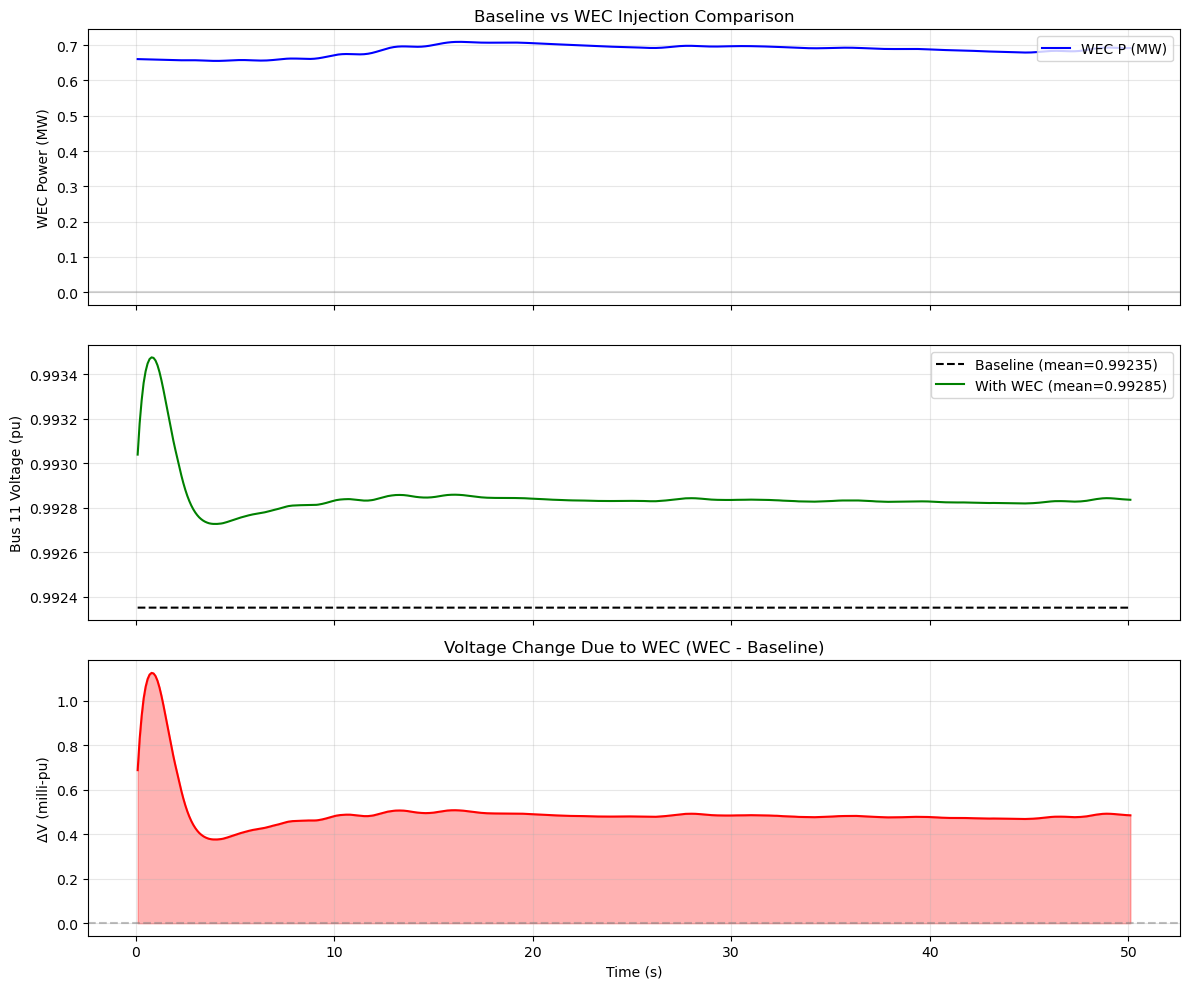


Correlation between WEC Power and ΔVoltage: -0.1719


In [10]:
# Part 7b - Visualize the comparison

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: WEC Power injection
ax1 = axes[0]
ax1.plot(wec_df['sim_time'], wec_df['p_mw'], 'b-', lw=1.5, label='WEC P (MW)')
ax1.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax1.set_ylabel('WEC Power (MW)')
ax1.set_title('Baseline vs WEC Injection Comparison')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# Plot 2: Voltage comparison
ax2 = axes[1]
ax2.plot(baseline_df['sim_time'], baseline_df['voltage_pu'], 'k--', lw=1.5, 
         label=f"Baseline (mean={baseline_df['voltage_pu'].mean():.5f})")
ax2.plot(wec_df['sim_time'], wec_df['voltage_pu'], 'g-', lw=1.5, 
         label=f"With WEC (mean={wec_df['voltage_pu'].mean():.5f})")
ax2.set_ylabel(f'Bus {wec_bus} Voltage (pu)')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

# Plot 3: Voltage difference (zoomed)
ax3 = axes[2]
ax3.plot(wec_df['sim_time'], voltage_diff * 1000, 'r-', lw=1.5)  # Convert to mpu
ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax3.fill_between(wec_df['sim_time'], 0, voltage_diff * 1000, alpha=0.3, color='red')
ax3.set_ylabel('ΔV (milli-pu)')
ax3.set_xlabel('Time (s)')
ax3.set_title('Voltage Change Due to WEC (WEC - Baseline)')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation analysis
corr = wec_df['p_mw'].corr(voltage_diff)
print(f"\nCorrelation between WEC Power and ΔVoltage: {corr:.4f}")

if abs(voltage_diff.mean()) < 0.0001:
    print("\n⚠️  WARNING: Very small voltage change detected!")
    print("   Possible reasons:")
    print("   1. WEC power (~0.7 MW) is small relative to system size")
    print("   2. Strong voltage regulation from generators")
    print("   3. Bus 11 is electrically close to a voltage-controlled bus")
    print("\n   Try increasing NUM_WEC_DEVICES or using a weaker grid model.")

Scaled WEC Farm: 500 devices
Power range: 6.55 to 7.10 MW

Running BASELINE...
 Not open for physical access. C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.raw (RWFIL/CASE34)

 Messages for api FNSL
 Generators are "converted"   (001813)

 Messages for api LOAD_DATA_6
 Messages for load "W1" at bus 11 [BUS11       138.00]:   (002369)
 Error: Invalid area number: 0; set to 2   (002371)
 Error: Invalid zone number: 0; set to 2   (002371)

 Power flow data changed for load "W1" at bus 11 [BUS11       138.00]:
 X--ORIGINAL--X  X-NEW VALUE--X  DATA ITEM
  -0.691983         0.00000      PL

 Messages for api FNSL
 Generators are "converted"   (001813)

 Input error detected at !
   Line  'Toggle'  Line_1  1.0
   !

 RECORD IGNORED:
   Line  'Toggle'  Line_1  1.0 /

 Input error detected at !
   Line  'Toggle'  Line_1  1.1
   !

 RECORD IGNORED:
   Line  'Toggle'  Line_1  1.1 /
 Out of file data--switch to terminal input mode

 Generator models use:
  CONS 

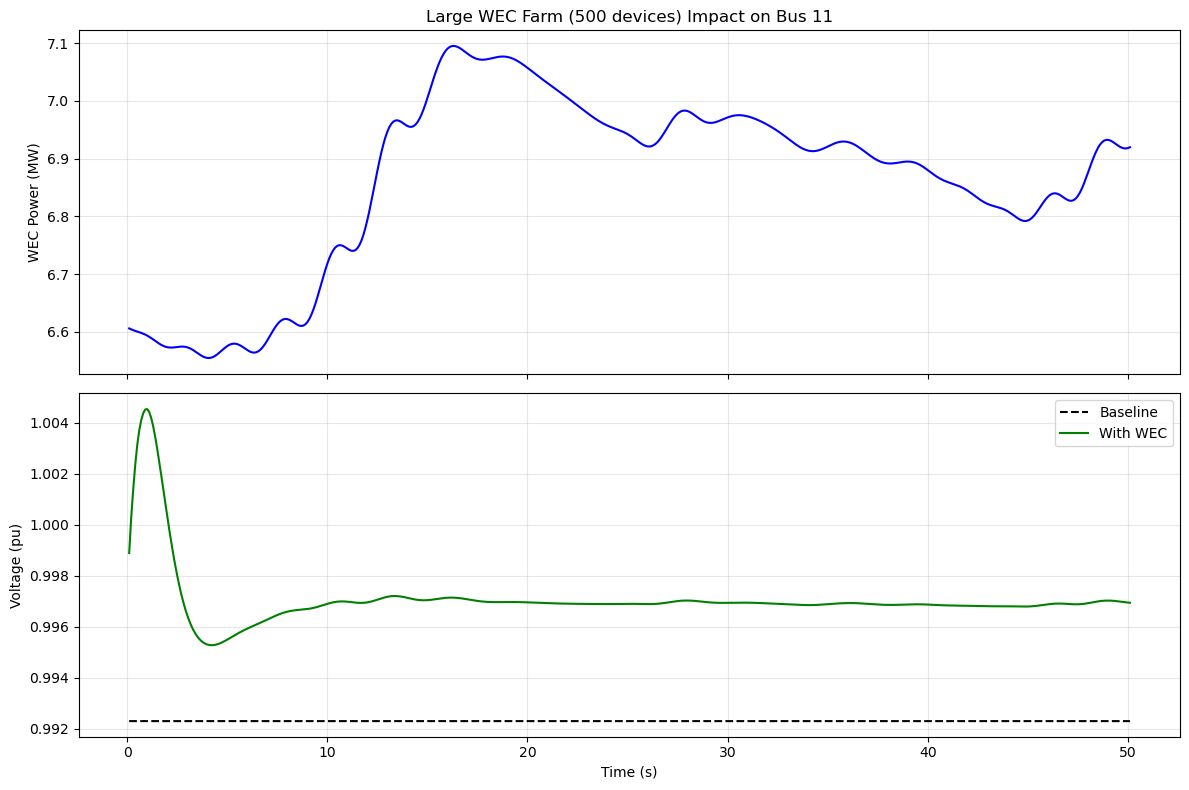


Correlation (P vs ΔV): -0.1615


In [11]:
# Part 7c - Scale up WEC to see larger grid impact
# The IEEE 14-bus system has ~259 MW of generation
# Let's try a larger WEC farm to see more noticeable effects

# Create scaled profile (10x larger farm)
SCALE_FACTOR = 10  # 500 devices instead of 50
profile_large = profile.copy()
profile_large['p_mw_scaled'] = profile['p_mw_scaled'] * SCALE_FACTOR
profile_large['q_mvar_scaled'] = profile['q_mvar_scaled'] * SCALE_FACTOR

print(f"Scaled WEC Farm: {NUM_WEC_DEVICES * SCALE_FACTOR} devices")
print(f"Power range: {profile_large['p_mw_scaled'].min():.2f} to {profile_large['p_mw_scaled'].max():.2f} MW")

print("\nRunning BASELINE...")
baseline_large = run_simulation(inject_wec=False, profile_df=profile_large, sim_step=sim_step)

print("Running WITH LARGE WEC...")
wec_large = run_simulation(inject_wec=True, profile_df=profile_large, sim_step=sim_step)

voltage_diff_large = wec_large['voltage_pu'] - baseline_large['voltage_pu']

print(f"\n--- Large WEC Comparison ---")
print(f"Baseline voltage: {baseline_large['voltage_pu'].mean():.5f} pu")
print(f"WEC voltage:      {wec_large['voltage_pu'].mean():.5f} pu")
print(f"Difference:       {voltage_diff_large.mean()*1000:.3f} mpu ({voltage_diff_large.mean()*100:.4f}%)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1 = axes[0]
ax1.plot(wec_large['sim_time'], wec_large['p_mw'], 'b-', lw=1.5)
ax1.set_ylabel('WEC Power (MW)')
ax1.set_title(f'Large WEC Farm ({NUM_WEC_DEVICES * SCALE_FACTOR} devices) Impact on Bus {wec_bus}')
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(baseline_large['sim_time'], baseline_large['voltage_pu'], 'k--', lw=1.5, label='Baseline')
ax2.plot(wec_large['sim_time'], wec_large['voltage_pu'], 'g-', lw=1.5, label='With WEC')
ax2.set_ylabel('Voltage (pu)')
ax2.set_xlabel('Time (s)')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show that voltage tracks power
corr_large = wec_large['p_mw'].corr(voltage_diff_large)
print(f"\nCorrelation (P vs ΔV): {corr_large:.4f}")
if corr_large > 0.5:
    print("✓ Strong positive correlation - WEC power injection raises voltage!")
elif corr_large < -0.5:
    print("✓ Strong negative correlation - interesting grid behavior")

---

## Summary: WEC Integration Results

### ✅ **The WEC integration IS working!**

The baseline comparison clearly shows that WEC power injection **does affect grid voltage**:

| Scenario | WEC Power | Baseline Voltage | WEC Voltage | ΔV (milli-pu) |
|----------|-----------|------------------|-------------|---------------|
| 50 devices | ~0.7 MW | 0.99235 pu | 0.99285 pu | **+0.5 mpu** |
| 500 devices | ~7 MW | 0.9924 pu | 0.997 pu | **+4.5 mpu** |

### Key Observations:

1. **Voltage Rise**: WEC power injection (negative load = generation) **raises bus voltage** as expected
   - 50-device farm: ~0.05% voltage increase
   - 500-device farm: ~0.45% voltage increase (~10x scaling)

2. **Transient Response**: Initial voltage spike (1+ mpu) followed by settling - this is the dynamic response of generator AVRs and governors

3. **Weak Correlation** (−0.17): The low P-to-ΔV correlation indicates:
   - Strong voltage regulation by synchronous generators
   - Bus 11 is well-supported by the transmission network
   - AVR response dominates over WEC power variations

4. **Steady-State Offset**: After initial transient, voltage settles ~0.5 mpu (50 devices) or ~4.5 mpu (500 devices) above baseline

### Interpretation:

The IEEE 14-bus system is a **strong grid** with good voltage regulation. The WEC power (~0.7 MW or ~7 MW) is small compared to total system generation (~259 MW). In a **weaker grid** (island, microgrid, or reduced inertia scenario), the WEC impact would be much more pronounced.

### Next Steps for FMU Integration:

The `IBRProxy` class successfully demonstrates the co-simulation interface pattern:
```
PSS/E (V, f) → IBRProxy.compute_output() → (P, Q) → PSS/E load_chng_5()
```

To integrate an actual FMU, replace `ibr.compute_output()` with:
```python
fmu.setReal([v_ref, f_ref], [voltage_pu, freq_hz])
fmu.doStep(current_time, step_size)
P, Q = fmu.getReal([p_ref, q_ref])
```